# <center>**Importing Essential Libraries and Defining Dataset Paths**</center>

In [2]:
# Standard libraries
import os
import re
import copy
import time
import random
from pathlib import Path
from collections import Counter, defaultdict
import shutil
import math


# Data handling
import pandas as pd
import numpy as np
from scipy.stats import skew
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pillow_heif

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.v2 as v2

# Enable HEIF/HEIC support
pillow_heif.register_heif_opener()

# ----------------------------
# Environment logging
# ----------------------------
print("=== Environment Info ===")
print(f"OS: {os.name}")
print(f"Python version: {os.sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

if torch.backends.mps.is_available():
    print("Apple GPU (MPS) available: Yes")
else:
    print("Apple GPU (MPS) available: No")

=== Environment Info ===
OS: posix
Python version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
PyTorch version: 2.5.1
Torchvision version: 0.20.1
Numpy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.9.2
Seaborn version: 0.13.2
Apple GPU (MPS) available: Yes


In [3]:
# ============================================================
# Project / Dataset Paths
# ============================================================

from dotenv import load_dotenv

# Permanent private configuration
CONFIG_FILE = Path.home() / ".wadidegla.env"

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Local WadiDegla configuration file was not found."
    )

load_dotenv(CONFIG_FILE)


DATA_DIR = Path(os.environ["WADIDEGLA_DATA_DIR"])
TRAIN_DIR = DATA_DIR / "Train"
VAL_DIR = DATA_DIR / "Validation"

WORKSPACE_DIR = Path(os.environ["WADIDEGLA_WORKSPACE_DIR"])

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "The configured WadiDegla dataset directory does not exist."
    )

if not WORKSPACE_DIR.exists():
    raise FileNotFoundError(
        "The configured WadiDegla experimental workspace directory does not exist."
    )

print("WadiDegla dataset configuration loaded successfully.")
print("WadiDegla experimental workspace configuration loaded successfully.")

WadiDegla dataset configuration loaded successfully.
WadiDegla experimental workspace configuration loaded successfully.


# **<center>Comparison</center>**

In [40]:
def plot_all_metrics_combined(models_summaries_dict, train_val):
    n_plots = 4

    fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(18, 5 * ((n_plots + 1) // 2)))
    axes = axes.flatten()

    plot_idx = 0

    # Use the epoch range from any model (assuming all have same epochs)
    example_epochs = next(iter(models_summaries_dict.values()))['Epoch']
    epoch_ticks = range(int(example_epochs.min()), int(example_epochs.max()) + 1)

    # ----------- Accuracy -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['Accuracy (micro)'], marker='o', label=f'{model_name}')
    ax.set_title(f'a) Accuracy (micro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Accuracy (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)
    plot_idx += 1

    # ----------- F1 (macro) -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['F1 (macro)'], marker='s', label=f'{model_name}')
    ax.set_title(f'b) F1-score (macro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('F1 (macro) (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)
    plot_idx += 1

    # ----------- Precision -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['Precision (macro)'], marker='^', label=f'{model_name}')
    ax.set_title(f'c) Precision (Macro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Precision (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)
    plot_idx += 1

    # ----------- Recall -----------
    ax = axes[plot_idx]
    for model_name, df in models_summaries_dict.items():
        ax.plot(df['Epoch'], df['Recall (macro)'], marker='v', label=f'{model_name}')
    ax.set_title(f'd) Recall (Macro)', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Recall (%)', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=15)

    # ----------- Clean up unused subplot if any -----------
    for idx in range(plot_idx + 1, len(axes)):
        fig.delaxes(axes[idx])

    # ----------- Layout & Save -----------
    fig.suptitle(f'{train_val} Metrics Across Epochs', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'Comparison/{train_val}_All_Metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

In [63]:
base_path = WORKSPACE_DIR / "Comparison/mobilenetv2"

In [65]:
VGG16_train_summary_full = pd.read_csv(base_path / 'vgg16_train_summary1_10.csv')

In [66]:
ResNet18_train_summary_full = pd.read_csv(base_path / 'resnet18_train_summary1_10.csv')

In [67]:
MobileNetV2_train_summary_1_5 = pd.read_csv(base_path / 'mobilenet_v2_train_summary1_5.csv')
MobileNetV2_train_summary_6_10 = pd.read_csv(base_path / 'mobilenet_v2_train_summary6_10.csv')
MobileNetV2_train_summary_full = pd.concat([MobileNetV2_train_summary_1_5, MobileNetV2_train_summary_6_10], ignore_index=True)

In [68]:
model_train_summaries = {
    "VGG16": VGG16_train_summary_full,
    "ResNet18": ResNet18_train_summary_full,
    "MobileNetV2": MobileNetV2_train_summary_full
}

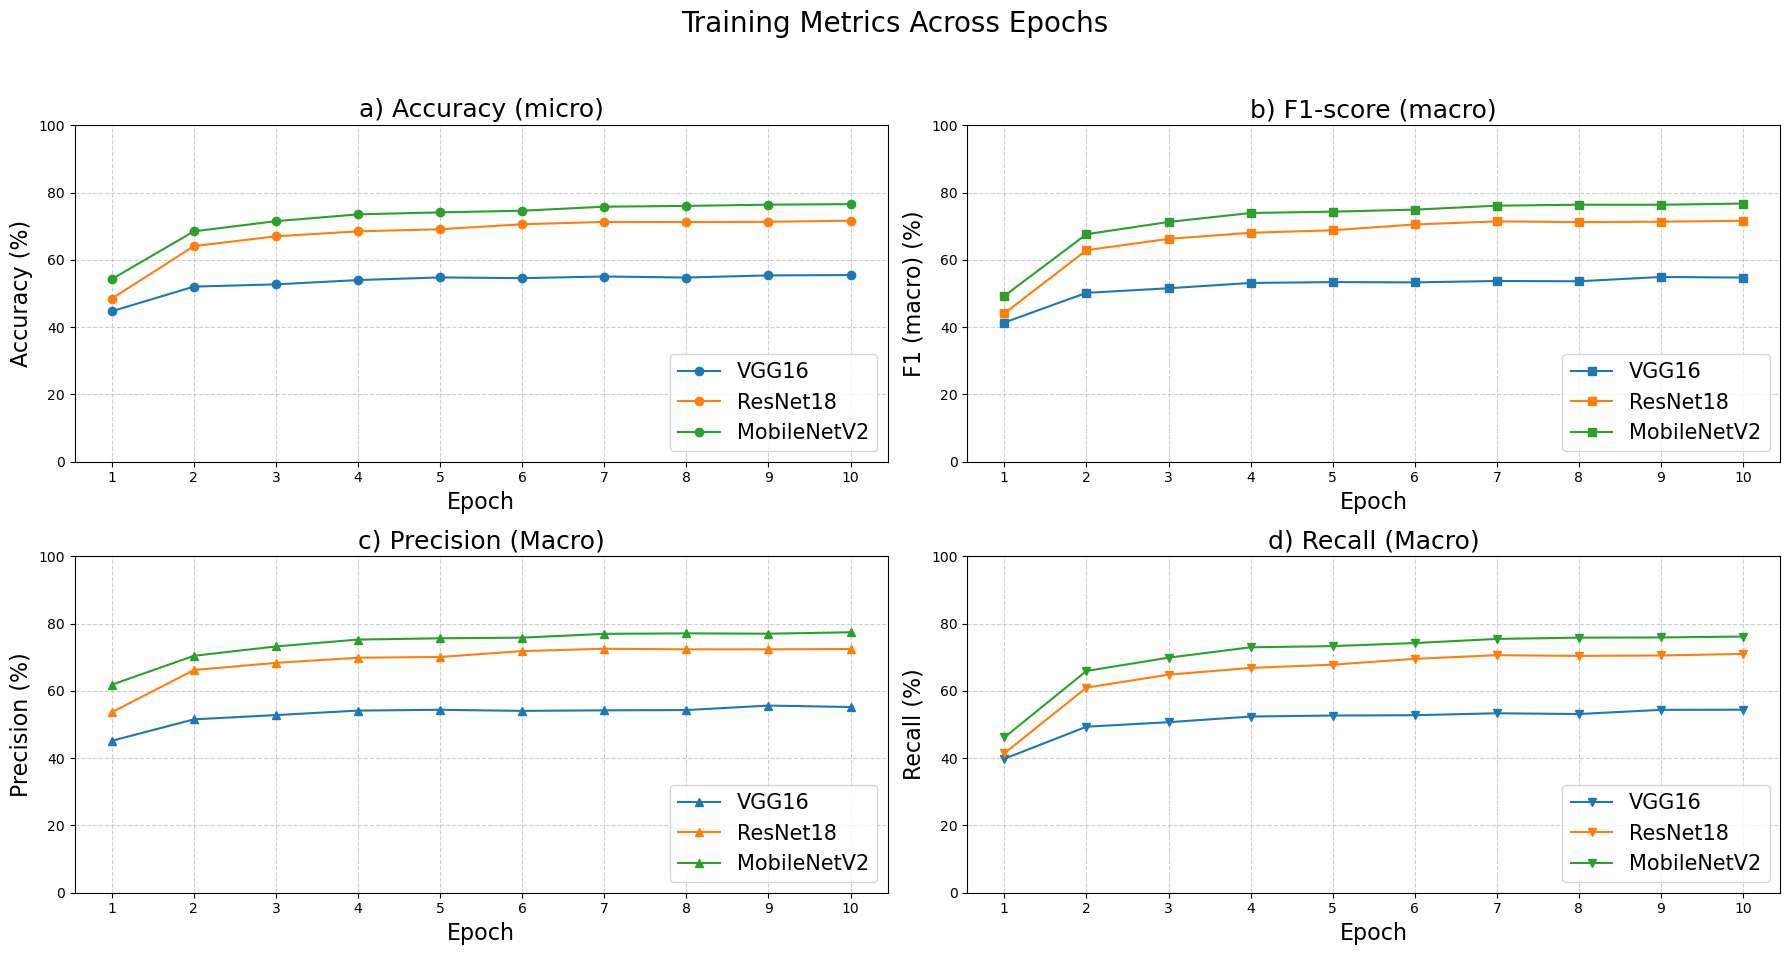

In [70]:
plot_all_metrics_combined(model_train_summaries, train_val="Training")

In [71]:
VGG16_val_summary_full = pd.read_csv(base_path / 'vgg16_val_summary1_10.csv')

In [72]:
VGG16_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']] = VGG16_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']]*100

In [73]:
ResNet18_val_summary_full = pd.read_csv(base_path / 'resnet18_val_summary1_10.csv')
ResNet18_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']] = ResNet18_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']]*100

In [74]:
MobileNetV2_val_summary_1_5 = pd.read_csv(base_path / 'mobilenet_v2_val_summary1_5.csv')
MobileNetV2_val_summary_6_10 = pd.read_csv(base_path / 'mobilenet_v2_val_summary6_10.csv')
MobileNetV2_val_summary_full = pd.concat([MobileNetV2_val_summary_1_5, MobileNetV2_val_summary_6_10], ignore_index=True)
MobileNetV2_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']] = MobileNetV2_val_summary_full[['Precision (macro)', 'Recall (macro)', 'F1 (macro)']]*100

In [75]:
model_val_summaries = {
    "VGG16": VGG16_val_summary_full,
    "ResNet18": ResNet18_val_summary_full,
    "MobileNetV2": MobileNetV2_val_summary_full
}

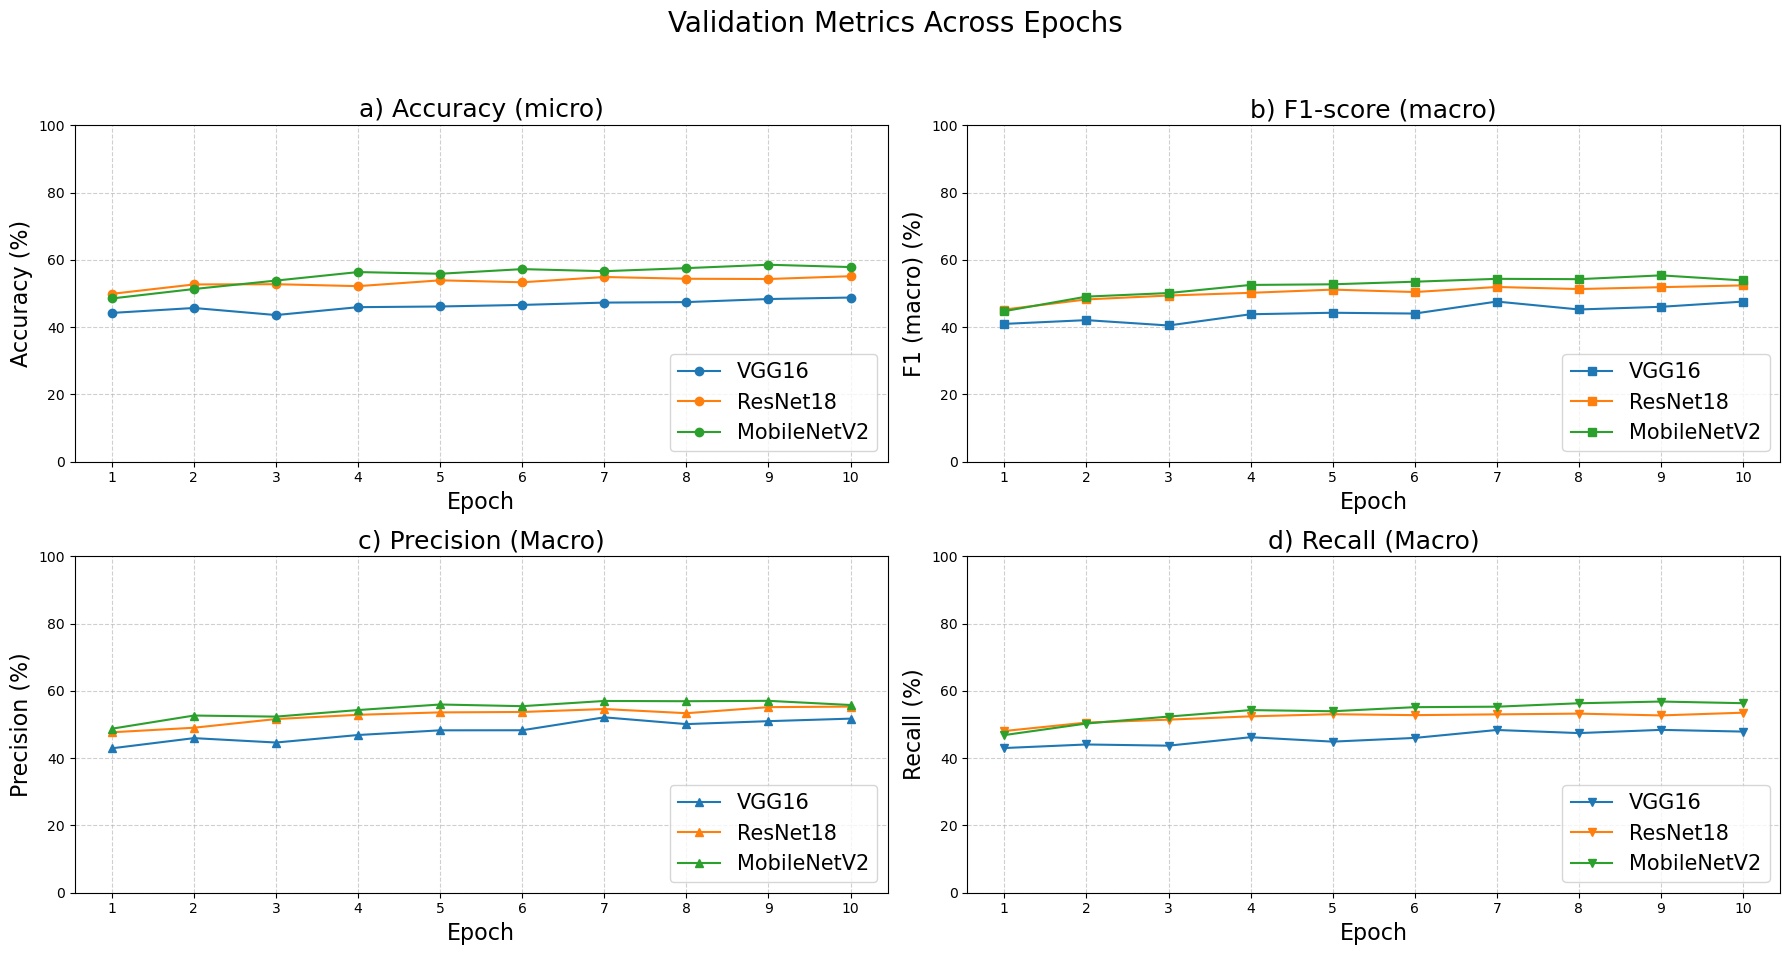

In [76]:
plot_all_metrics_combined(model_val_summaries, train_val="Validation")

In [77]:
def plot_loss(model_train_summaries, model_val_summaries , data="Wadi Degla"):
    n_plots = 2

    fig, axes = plt.subplots((n_plots + 1) // 2, 2, figsize=(18, 6 * ((n_plots + 1) // 2)))
    axes = axes.flatten()

    plot_idx = 0

    # Use the epoch range from any model (assuming all have same epochs)
    example_epochs = next(iter(model_train_summaries.values()))['Epoch']
    epoch_ticks = range(int(example_epochs.min()), int(example_epochs.max()) + 1)

    
    ax = axes[plot_idx]
    for model_name, df in model_train_summaries.items():
        ax.plot(df['Epoch'], df['Loss'], marker='d', linestyle='--', label=f'{model_name}')
    ax.set_title(f'a) Training Loss', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='center right', fontsize=15, bbox_to_anchor=(1, 0.35))
    plot_idx += 1

    ax = axes[plot_idx]
    for model_name, df in model_val_summaries.items():
        ax.plot(df['Epoch'], df['Loss'], marker='d', linestyle='--', label=f'{model_name}')
    ax.set_title(f'b) Validation Loss', fontsize=18)
    ax.set_xlabel('Epoch', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_xticks(epoch_ticks)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='center right', fontsize=15, bbox_to_anchor=(1, 0.35))

    # ----------- Layout & Save -----------
    fig.suptitle(f'Training & Validation Loss Across Epochs', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'Comparison/Train & Validation {data} Loss.png', dpi=300, bbox_inches='tight')
    plt.show()

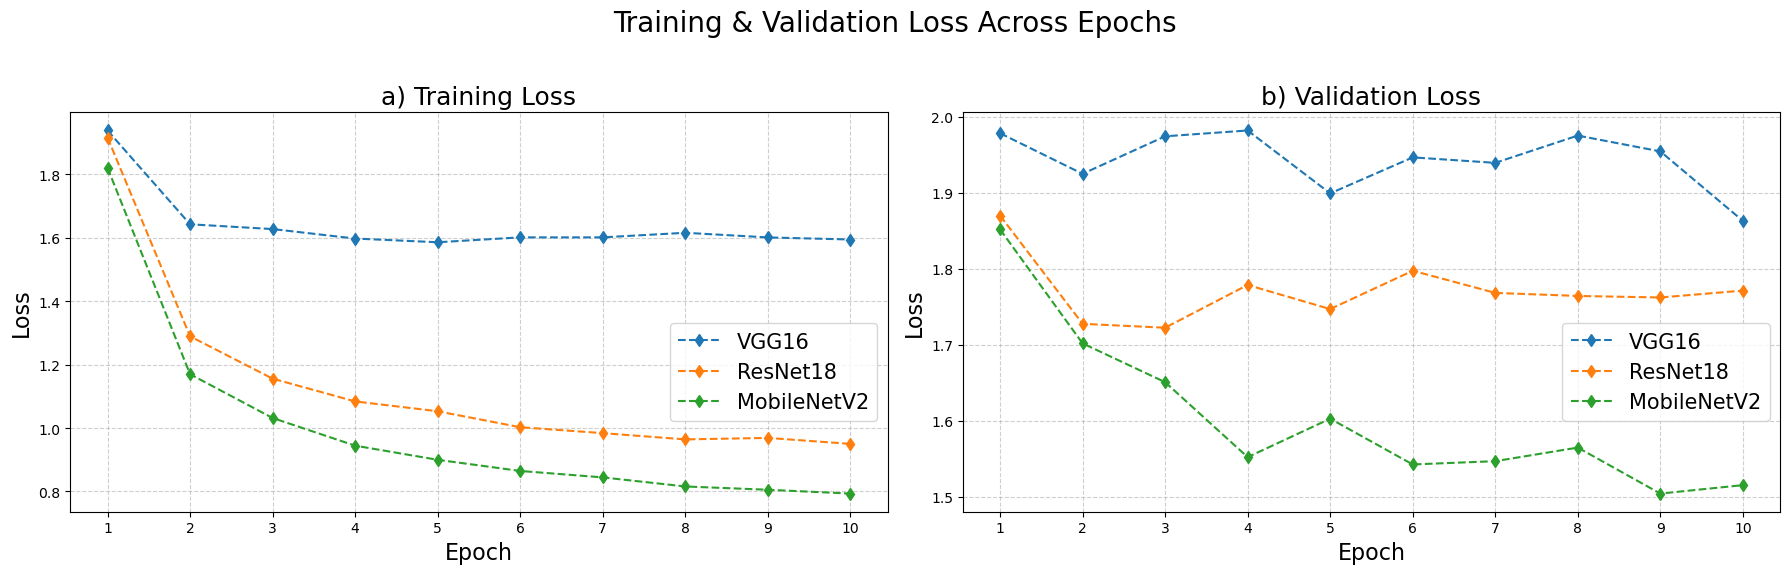

In [78]:
plot_loss(model_train_summaries, model_val_summaries)

| Feature                     | VGG16                              | ResNet-18                           | MobileNetV2                         |
|----------------------------|------------------------------------|-------------------------------------|--------------------------------------|
| **Train Accuracy (%)**     | 55.50                              |             71.66                   | 76.57                                |
| **Validation Accuracy (%)**      | 48.81                              | 55.15                               | 57.87                                |
| **Architecture Type**      | Convolutional (very deep)          | Residual (skip connections)         | Depthwise Separable Convolutions     |
| **Model Size**             | ~537.6 MB                          | ~44.9 MB                            | ~9.3 MB                              |
| **Parameters**             | ~134.40 million                     | ~11.19 million                     | ~2.27 million                        |

In [79]:
def plot_train_val_bars(train_summaries, val_summaries, epoch):
    """
    Compare model performance (Train vs Validation) at a specific epoch using side-by-side bar charts.

    Args:
        train_summaries (dict): {model_name: pandas.DataFrame} for training metrics.
        val_summaries (dict): {model_name: pandas.DataFrame} for val metrics.
        epoch (int): epoch number to visualize.
    """
    metrics = ['Accuracy (micro)', 'F1 (macro)', 'Precision (macro)', 'Recall (macro)']
    metric_labels = ['Accuracy', 'F1-score', 'Precision', 'Recall']

    def extract_metrics(models_summaries_dict):
        model_names = list(models_summaries_dict.keys())
        values = {model: [] for model in model_names}

        for model_name, df in models_summaries_dict.items():
            if epoch not in df['Epoch'].values:
                print(f"⚠️ Warning: Epoch {epoch} not found for {model_name}, skipping.")
                model_names.remove(model_name)
                continue
            row = df[df['Epoch'] == epoch].iloc[0]
            values[model_name] = [row[m] for m in metrics]
        return model_names, values

    train_models, train_values = extract_metrics(train_summaries)
    val_models, val_values = extract_metrics(val_summaries)

    x = np.arange(len(metrics))
    bar_width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Model Comparison at Epoch {epoch}', fontsize=20)

    # ---------- Helper function ----------
    def plot_one(ax, data_values, model_names, title):
        for i, model_name in enumerate(model_names):
            offset = (i - len(model_names) / 2) * bar_width + bar_width / 2
            ax.bar(x + offset, data_values[model_name], width=bar_width, label=model_name)

        ax.set_title(title, fontsize=18)
        ax.set_xlabel('Metric', fontsize=16)
        ax.set_ylabel('Score (%)', fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_labels)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=15)

    # ---------- Plot train and val ----------
    plot_one(axes[0], train_values, train_models, "a) Training Metrics")
    plot_one(axes[1], val_values, val_models, "b) Validation Metrics")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f'Comparison/Metrics_Comparison_Epoch_{epoch}.png', dpi=300, bbox_inches='tight')
    plt.show()

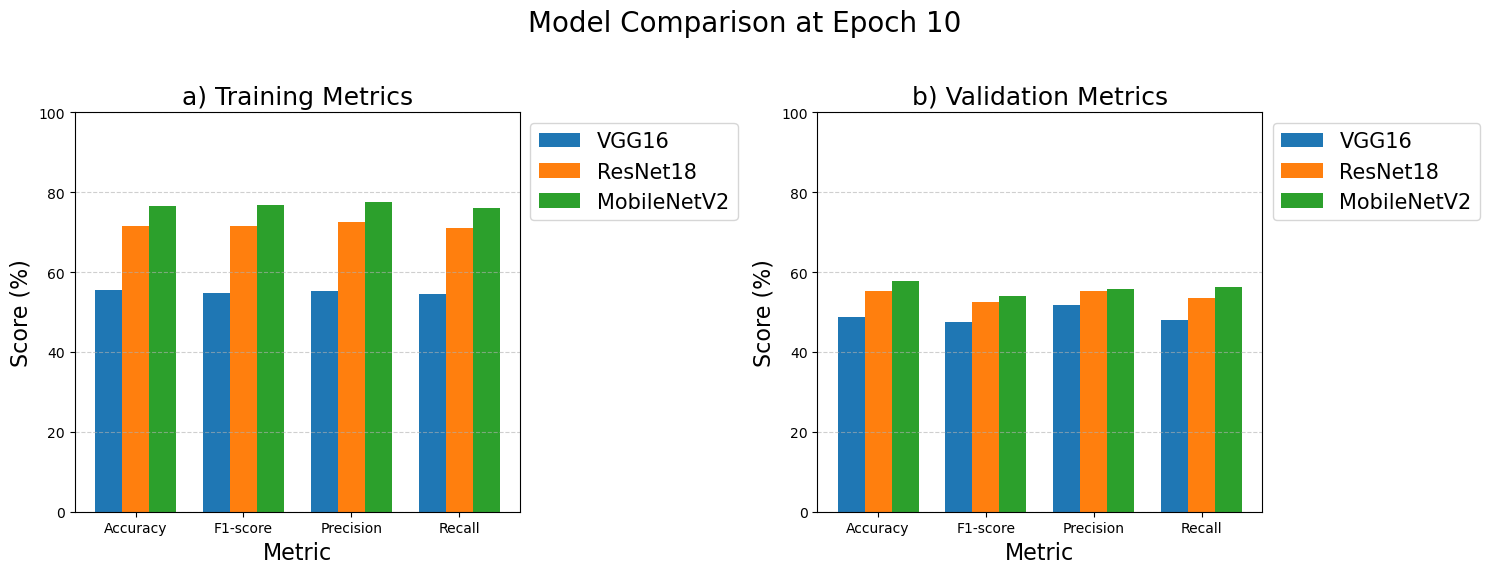

In [80]:
plot_train_val_bars(model_train_summaries, model_val_summaries, epoch=10)